# Data Workflow for Swiss Legal Entity Identifier (LEI) Data

**Author:** Mauro Reverberi

**Dataset:** GLEIF LEI Golden Copy (Level 1, "Who is who"), filtered to Swiss entities:
https://www.gleif.org/en/lei-data/gleif-golden-copy/download-the-golden-copy

The LEI is a global identification code for legal entities that take part in
financial transactions. In this notebook I work with the official GLEIF dataset,
filtered down to entities registered in Switzerland. I load the prepared data,
clean it, explore it and create some visualizations. I chose this dataset
because I want to build on it in the later capstone projects, where the topic
will be entity matching for compliance checks.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Ingestion

I downloaded the Golden Copy on 2026-08-06, at that point it contained
3,395,297 records worldwide. GLEIF publishes the data under a CC0 license,
so it is fine to use it for an academic project. The raw file is around 5 GB,
so I do not load it here directly: `prepare_dataset.py` filters it down to
the Swiss entities first, and the notebook only works with the result of
that script (`lei_switzerland.csv`).

In [2]:
df = pd.read_csv("lei_switzerland.csv")
df.head()

,lei,legal_name,legal_form_code,entity_category,entity_status,city,postal_code,registration_status,initial_registration_date,last_update_date,next_renewal_date,managing_lou
0,031K640IPWCPFDXYCT54,CELGENE LOGISTICS SÀRL,3EKS,GENERAL,ACTIVE,BOUDRY,2017,LAPSED,2012-11-21T15:05:00Z,2025-11-17T13:36:01.070Z,2020-04-30T02:56:00Z,213800WAVVOPS85N2205
1,0F6ULKRCPAMK7RS2NU33,VVA - OBLIGATIONEN USD,8888,FUND,INACTIVE,BASEL,4052,RETIRED,2012-11-29T11:34:00Z,2024-12-16T17:06:10.993Z,2014-12-24T15:01:00Z,213800WAVVOPS85N2205
2,0O4V58H21DEPN9HFSQ45,NEW CAPITAL MULTIBOND EUR,8888,FUND,INACTIVE,ADLISWIL,8134,RETIRED,2012-11-29T11:34:00Z,2024-12-16T17:06:10.993Z,2018-11-07T00:37:00Z,213800WAVVOPS85N2205
3,0T1CG46EXJPKIM1GY234,WORLD HEALTH ORGANIZATION (WHO),9999,INTERNATIONAL_ORGANIZATION,ACTIVE,GENEVA,1211,ISSUED,2012-11-19T14:06:00Z,2026-02-03T06:51:07.987Z,2027-03-29T00:00:00Z,213800WAVVOPS85N2205
4,0WWZ9WRSWZSADGTPNI62,MORGAN STANLEY (SWITZERLAND) GmbH,3EKS,GENERAL,ACTIVE,Zurich,8002,ISSUED,2012-06-06T15:52:00.000Z,2025-10-15T19:06:18.725Z,2026-11-15T08:32:00.000Z,5493001KJTIIGC8Y1R12


In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.dtypes

Rows: 27933, Columns: 12


lei                          str
legal_name                   str
legal_form_code              str
entity_category              str
entity_status                str
city                         str
postal_code                  str
registration_status          str
initial_registration_date    str
last_update_date             str
next_renewal_date            str
managing_lou                 str
dtype: object

The dataset is much larger than the required minimum of 200 rows and 5
columns: 27,933 rows and 12 columns. At the moment every column is just a
string. I will convert the three date columns into real datetime types in
the Cleaning section.

## Cleaning

In this section I define two cleaning functions and apply them to the
dataset. Both functions work on a copy, so the original loaded data stays
untouched.

In [4]:
# some legal names contain curly quotes or « », I map them all to normal quotes
QUOTE_TRANSLATION = str.maketrans(
    {char: '"' for char in "“”„«»"}
    | {char: "'" for char in "‘’"}
)

# typical legal form suffixes at the end of Swiss company names, written
# without a trailing dot because the dots get stripped before comparing
LEGAL_SUFFIXES = {
    "ag", "sa", "s.a", "gmbh", "sarl", "sàrl", "sagl",
    "ltd", "inc", "llc", "plc", "se",
}


def clean_legal_names(df):
    """Clean the legal_name column and add a normalized version of it.

    Strips extra whitespace, replaces the inconsistent quote characters and
    adds a new column 'legal_name_normalized' (lowercase, without the legal
    form suffix) that I can use for grouping and duplicate checks. Returns
    a cleaned copy of the DataFrame, the original rows are not changed.
    """
    result = df.copy()
    cleaned = (
        result["legal_name"]
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .str.translate(QUOTE_TRANSLATION)
    )
    result["legal_name"] = cleaned

    def strip_suffix(name):
        """Cut suffixes like 'ag' or 'gmbh' from the end of a lowercase name."""
        tokens = name.split()
        while len(tokens) > 1 and tokens[-1].strip("().,") in LEGAL_SUFFIXES:
            tokens = tokens[:-1]
        return " ".join(tokens)

    result["legal_name_normalized"] = cleaned.str.lower().map(strip_suffix)
    return result

In [5]:
names_before = df["legal_name"].copy()
df = clean_legal_names(df)

changed = names_before != df["legal_name"]
print(f"{changed.sum()} of {len(df)} names changed by the cleaning")
print(f"duplicate names before normalization: {names_before.duplicated().sum()}")
print(f"duplicate names after normalization: {df['legal_name_normalized'].duplicated().sum()}")

# show a few of the changed names before and after
pd.DataFrame({"before": names_before[changed], "after": df.loc[changed, "legal_name"]}).head()

7 of 27933 names changed by the cleaning
duplicate names before normalization: 144
duplicate names after normalization: 209


,before,after
95,BNY MELLON INVESTMENTS SWITZERLAND GMBH,BNY MELLON INVESTMENTS SWITZERLAND GMBH
1030,JOHNSON CONTROLS SYSTEMS & SERVICE GMBH,JOHNSON CONTROLS SYSTEMS & SERVICE GMBH
1469,RP - Fonds Institutionnel - Obligations d’entr...,RP - Fonds Institutionnel - Obligations d'entr...
3533,UBS (CH) Property Fund – Swiss Commercial «Int...,"UBS (CH) Property Fund – Swiss Commercial ""Int..."
3630,UBS (CH) Property Fund – Swiss Residential «Siat»,"UBS (CH) Property Fund – Swiss Residential ""Siat"""


**Why this cleaning was needed:** the before/after sample shows what was
wrong in the raw names: extra whitespace and mixed quote styles (curly
quotes, `«»`). Only 7 names were affected by that, so the bigger problem is
actually another one. Capitalization and legal form suffixes like AG, GmbH
or Sàrl are not used consistently across the records, and without
normalization the same company can show up as two different groups in the
EDA, and also later when I try to match entities between data sources. That
is what the new `legal_name_normalized` column is for. After lowercasing
and removing the suffix, the count of rows with a duplicated name goes up
from 144 to 209, so the normalization makes 65 additional rows repeat a
name that already exists. To be clear, a matching name alone does not
prove a duplicate. A stronger check would also compare the legal form,
the legal address and the register data (that duplicates are a real topic shows
the dataset itself, it contains 100 records with the official status
DUPLICATE). The normalized name only helps to find candidates in the
first place. The original `legal_name` stays as it is (except the
whitespace/quote fixes), so nothing gets lost.

In [6]:
DATE_COLUMNS = ["initial_registration_date", "last_update_date", "next_renewal_date"]


def parse_registration_dates(df):
    """Convert the three registration date columns from string to datetime.

    Invalid values do not raise an error, they become NaT (errors="coerce")
    and I print how many there are per column, so nothing gets lost
    silently. Also adds a 'registration_year' column that I need later for
    the registrations-per-year plot. Returns a copy of the DataFrame.
    """
    result = df.copy()
    for column in DATE_COLUMNS:
        raw_missing = result[column].isna().sum()
        parsed = pd.to_datetime(
            result[column], errors="coerce", format="ISO8601", utc=True
        )
        unparseable = parsed.isna().sum() - raw_missing
        print(f"{column}: {unparseable} values could not be parsed")
        result[column] = parsed
    result["registration_year"] = result["initial_registration_date"].dt.year
    return result

In [7]:
df = parse_registration_dates(df)

print()
print(df[DATE_COLUMNS + ["registration_year"]].dtypes)

# quick sanity check that the date ranges look plausible
df[DATE_COLUMNS].agg(["min", "max"])

initial_registration_date: 0 values could not be parsed
last_update_date: 0 values could not be parsed
next_renewal_date: 0 values could not be parsed

initial_registration_date    datetime64[us, UTC]
last_update_date             datetime64[us, UTC]
next_renewal_date            datetime64[us, UTC]
registration_year                          int32
dtype: object


,initial_registration_date,last_update_date,next_renewal_date
min,2012-06-06 00:00:00+00:00,2017-10-09 17:08:29+00:00,2013-09-19 14:09:00+00:00
max,2026-08-05 12:48:21+00:00,2026-08-05 17:25:51+00:00,2027-10-04 11:15:30+00:00


**Why this cleaning was needed:** in the raw export the three date columns
are just strings, and not even in one consistent format. Some values have
milliseconds, some do not (visible in the `df.head()` output above). As long
as they are strings I cannot sort them, extract the year or check ranges.
`pd.to_datetime` with `errors="coerce"` turns them into real UTC timestamps,
and invalid values would become NaT instead of crashing the notebook. The
printout shows 0 such values, so the date columns are actually in very good
shape, which is good to know before I rely on them. I also added the
`registration_year` column because I will need it later when I look at the
registrations per year. The min/max check looks plausible. The first
registrations are from June 2012, when the LEI system started, and the
latest dates are close to the download date.

## EDA

For the exploration I wrote one reusable function that summarizes a
categorical column. It reports the missing values and shows the count and
percentage share of the most frequent values. I apply it to three columns
and write down after each one what I see in the output.

In [8]:
def explore_categorical(df, column, top_n=10):
    """Give a quick overview of one categorical column.

    First prints how many values are missing in the column, then returns
    a small DataFrame with the top_n most frequent values, their row count
    and their share of the whole dataset in percent.
    """
    n_missing = df[column].isna().sum()
    print(
        f"{column}: {n_missing} missing values "
        f"({100 * n_missing / len(df):.2f}% of {len(df)} rows)"
    )
    counts = df[column].value_counts().head(top_n)
    summary = pd.DataFrame(
        {"count": counts, "share_pct": (100 * counts / len(df)).round(2)}
    )
    summary.index.name = column
    return summary

In [9]:
explore_categorical(df, "legal_form_code")

legal_form_code: 0 missing values (0.00% of 27933 rows)


,count,share_pct
legal_form_code,,
MVII,15183,54.36
3EKS,3386,12.12
2JZ4,2501,8.95
9999,1424,5.10
FJG4,1377,4.93
FLNB,1351,4.84
8888,1300,4.65
H781,467,1.67
QSI2,344,1.23


More than half of all entries share one single legal form code: `MVII` with
15,183 entities (54.4%). This is the code for the classic Swiss stock
corporation (AG / SA). Second place is `3EKS` (GmbH / Sàrl) with 12.1%,
already far behind. I also find the two reserved codes interesting. In the
current GLEIF code list `8888` is used while a new code for a legal form
is requested, and `9999` stands for entities without a separate legal
form. The meaning of both codes changed with version 1.5 of the code
list. Together they cover almost 10% of the records. The column has no
missing values at all.

In [10]:
explore_categorical(df, "registration_status")

registration_status: 0 missing values (0.00% of 27933 rows)


,count,share_pct
registration_status,,
ISSUED,17737,63.50
LAPSED,7635,27.33
RETIRED,2442,8.74
DUPLICATE,100,0.36
ANNULLED,19,0.07


Only 63.5% of the registrations are `ISSUED`, so actively maintained. A
surprisingly large part (27.3%) is `LAPSED`, which only means that the
annual renewal was not done. The company itself can still exist, and a
lapsed registration can even go back to issued after a renewal. `RETIRED`
(8.7%) is the real end state. These entities do not operate anymore.
`DUPLICATE` and `ANNULLED` are rare. For me the high lapsed share is the
most important warning in this dataset. Whoever uses the registry must be
careful not to read "lapsed" as "company is gone".

In [11]:
explore_categorical(df, "city")

city: 0 missing values (0.00% of 27933 rows)


,count,share_pct
city,,
Zürich,3291,11.78
Zug,2193,7.85
Basel,1636,5.86
Genève,1399,5.01
Geneva,754,2.70
GENEVA,742,2.66
Lugano,651,2.33
Baar,617,2.21
Zurich,592,2.12


The city column has a data quality problem that I did not expect in an
official registry: the same city appears in several spellings. Zürich is
split into "Zürich" (3,291) and "Zurich" (592), and Geneva even shows up
three times in the top 10, as "Genève" (1,399), "Geneva" (754) and "GENEVA"
(742). So before any geographic analysis this column would need the same
kind of normalization as the legal names. Another point I found is the small city of
Zug is on second place (2,193 entities), clearly ahead of Basel and Geneva.
My guess is that the low company taxes play a role here, but I did not
test this with data.

In [12]:
# how many different spellings hide behind the two biggest cities?
zurich_variants = df.loc[
    df["city"].str.contains(r"z[uü]e?rich|zã¼rich", case=False, regex=True), "city"
].value_counts()
geneva_variants = df.loc[
    df["city"].str.contains(r"gen[eè]v", case=False, regex=True), "city"
].value_counts()

print("Raw spellings referring to Zürich:")
print(zurich_variants.to_string())
print("\nRaw spellings referring to Geneva:")
print(geneva_variants.to_string())

Raw spellings referring to Zürich:
city
Zürich              3291
Zurich               592
ZURICH               465
ZÜRICH               459
Zuerich                9
Zürich-Flughafen       6
Egg b. Zürich          3
OBERIEDEN-ZURICH       1
ZÃ¼rich                1
zurich                 1
ZUERICH                1
Küsnacht Zürich        1

Raw spellings referring to Geneva:
city
Genève                       1399
Geneva                        754
GENEVA                        742
Bellevue (Genève)             109
GENÈVE                         97
Geneve                         68
GENEVE                         65
Genève 73                      15
Geneva 3                        6
Genève 15 Aéroport              6
Geneva 73                       5
Geneva 12                       2
GENEVA 73                       1
GENEVA 1                        1
1201 Geneva                     1
GENEVE 11                       1
Geneva 11                       1
Geneva 2                        1
Genève 

This query shows how big the problem really is: Zürich alone appears in
eight different spellings, including "Zuerich" written without the umlaut
and one entry with broken encoding ("ZÃ¼rich"). For Geneva I count over
twenty different strings if I also include postal district entries like
"Genève 73". A few of the matches are real other places ("Bellevue
(Genève)", "Les Genevez JU"), so my search pattern is not perfect, but it
is good enough to show the size of the problem. The broken "ZÃ¼rich"
surprised me the most, that is a classic encoding error and not something
I expected in a regulated registry. It really is in the source data and
not a reading mistake on my side. If my UTF-8 import was wrong, all 3,291
correct "Zürich" values would be broken too, not just this single one.

## Visualizations

I create three figures and give them numbers so I can refer to them later
in the summary and in the report. The legal form composition (Figure 1),
the registrations over time (Figure 2) and the registration status per
legal form (Figure 3).

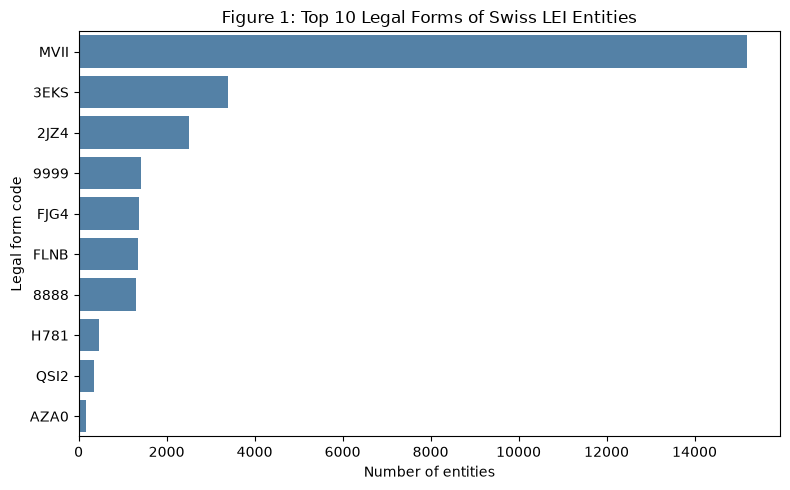

In [13]:
top_forms = df["legal_form_code"].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_forms.values, y=top_forms.index, color="steelblue", orient="h")
plt.title("Figure 1: Top 10 Legal Forms of Swiss LEI Entities")
plt.xlabel("Number of entities")
plt.ylabel("Legal form code")
plt.tight_layout()
plt.show()

**Interpretation:** the chart makes the imbalance from the EDA table even
more visible. The `MVII` bar (stock corporations) is more than four times
longer than the one for `3EKS` (GmbH / Sàrl), 15,183 against 3,386
entities. After that the bars drop quickly, every other legal form stays
below 2,600 entities. So the Swiss LEI population consists mostly of
normal incorporated companies, plus a smaller mix of foundations, trusts
and fund structures.

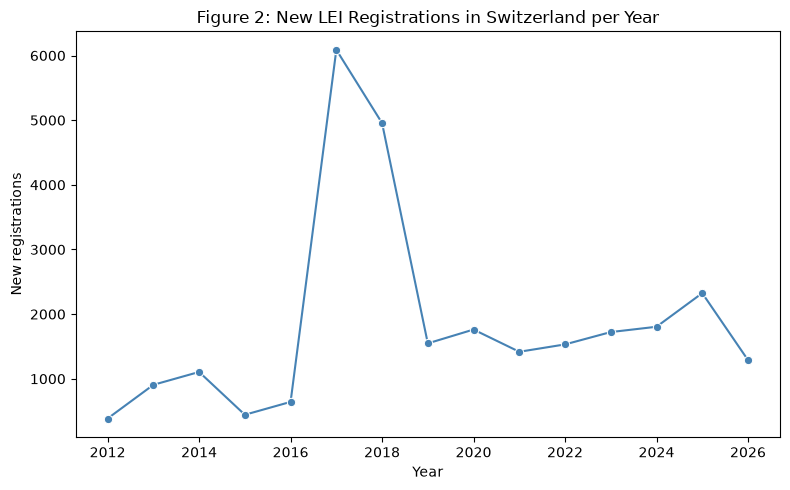

share of 2017 and 2018 together: 39.5%


In [14]:
per_year = df["registration_year"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.lineplot(x=per_year.index, y=per_year.values, marker="o", color="steelblue")
plt.title("Figure 2: New LEI Registrations in Switzerland per Year")
plt.xlabel("Year")
plt.ylabel("New registrations")
plt.tight_layout()
plt.show()

# how much of the total do the two spike years cover?
share_spike = 100 * (per_year[2017] + per_year[2018]) / per_year.sum()
print(f"share of 2017 and 2018 together: {share_spike:.1f}%")

**Interpretation:** the registrations do not grow evenly at all, the line
is dominated by one huge spike. After a slow start (386 registrations in
2012, low point of 444 in 2015), the numbers jump to 6,089 in 2017 and
4,955 in 2018. That is almost 40% of all Swiss LEIs in only two years. The
timing fits the EU MiFID II reporting rule ("no LEI, no trade") that
started in January 2018. Whoever wanted to keep trading with EU
counterparties needed an LEI before that date. From 2019 on the curve
stays in a range of roughly 1,400 to 2,300 per year. The low value for
2026 is not a real drop, the year is simply not over yet (I downloaded
the data on 6 August 2026).

In [15]:
# second explanation for the spike: who issued all these LEIs?
fso = "506700LOLO7M6V0E4247"  # LEI of the Swiss Federal Statistical Office ("LEI-Suisse")
fso_per_year = df[df["managing_lou"] == fso]["registration_year"].value_counts().sort_index()
print(fso_per_year.loc[2014:2020].to_string())
print(f"\nFSO share of all Swiss LEIs today: {100 * (df['managing_lou'] == fso).mean():.1f}%")

registration_year
2014      76
2015      40
2016     115
2017    2916
2018    2714
2019     692
2020     713

FSO share of all Swiss LEIs today: 41.0%


There is also a second, Swiss-specific part of the explanation, which I
know because I work on this system professionally. In 2017 the Federal
Statistical Office (FSO) was accredited as the national issuing
organization ("LEI-Suisse"). The numbers above show it clearly. The FSO
issued 115 Swiss LEIs in 2016 and 2,916 in 2017, and today it manages 41%
of all Swiss LEIs. My analysis cannot prove what caused what, but the
spike lines up with both events, MiFID II on the demand side and the new
Swiss issuing organization on the supply side.

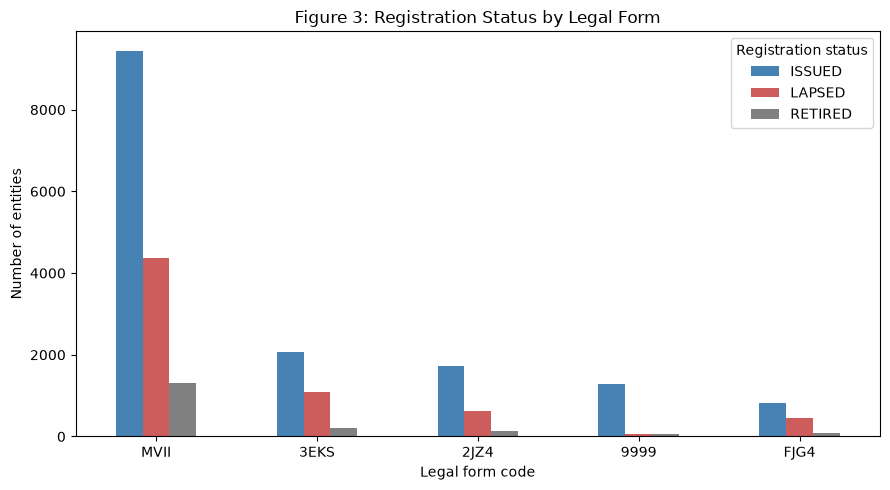

registration_status  ISSUED  LAPSED  RETIRED
legal_form_code                             
MVII                   62.2    28.8      8.6
3EKS                   61.0    32.3      6.2
2JZ4                   69.2    25.2      5.5
9999                   89.9     5.1      4.6
FJG4                   59.4    33.2      7.0


In [16]:
top5_forms = df["legal_form_code"].value_counts().head(5).index
subset = df[df["legal_form_code"].isin(top5_forms)]
status_by_form = pd.crosstab(
    subset["legal_form_code"], subset["registration_status"]
).loc[top5_forms, ["ISSUED", "LAPSED", "RETIRED"]]

status_by_form.plot(
    kind="bar", figsize=(9, 5), color=["steelblue", "indianred", "gray"]
)
plt.title("Figure 3: Registration Status by Legal Form")
plt.xlabel("Legal form code")
plt.ylabel("Number of entities")
plt.xticks(rotation=0)
plt.legend(title="Registration status")
plt.tight_layout()
plt.show()

# the chart shows counts, so I also print the shares in percent
all_statuses = pd.crosstab(subset["legal_form_code"], subset["registration_status"])
shares = (all_statuses.div(all_statuses.sum(axis=1), axis=0) * 100).round(1)
print(shares.loc[top5_forms, ["ISSUED", "LAPSED", "RETIRED"]].to_string())

**Interpretation:** the lapsed share differs clearly between the legal
forms. I only plot the three main statuses here, DUPLICATE and ANNULLED
together are below 0.5%. The chart shows absolute counts, so I printed
the shares in percent below it. Trusts (`FJG4`) and GmbH / Sàrl companies
(`3EKS`) have the highest lapsed shares with 33% and 32%, stock
corporations (`MVII`) are at 29% and foundations (`2JZ4`) at 25%. In
absolute numbers `MVII` has the most retired entries (1,308), which fits
its dominant share of the dataset. The clear outlier is the reserved code
`9999` (entities without a separate legal form). Only 5% lapsed and 90%
issued. My first idea was that these are simply newer registrations, but
the data shows the opposite, so I took a closer look.

In [ ]:
# what is behind the reserved code 9999?
code9999 = df[df["legal_form_code"] == "9999"]
print(code9999["entity_category"].value_counts().to_string())
print(f"\nshare managed by one single LOU: {100 * code9999['managing_lou'].value_counts(normalize=True).iloc[0]:.0f}%")
print(f"registered in 2017 or earlier: {100 * (code9999['registration_year'] <= 2017).mean():.0f}%")
print("\nnew 9999 registrations per year:")
print(code9999["registration_year"].value_counts().sort_index().to_string())

The picture is now much clearer. Almost all `9999` records are funds
(1,348 of 1,424), 96% of them sit with one single managing LOU, and 60%
were registered in 2017 or earlier, with a sharp drop after 2017. Two
facts from GLEIF help to read this. Today `9999` officially stands for
entities without a separate legal form, and the meaning of the reserved
codes changed with version 1.5 of the code list. What my dataset cannot
show is when the current code of these records was assigned, it only
contains the codes of today's snapshot. For the very low lapsed share my
explanation is the professional fund administration behind these records,
which renews the LEIs reliably. This is a hypothesis, not a result of my
analysis.

## Summary and Interpretation

**What I learned.** The Swiss LEI dataset contains 27,933 entities and is
dominated by a few legal forms. Stock corporations alone make up 54% of
all records, the top two forms together roughly two thirds (Figure 1).
The structure of the data is in a good state (no missing identifiers, all
dates parse), but the text columns are not. Names and city spellings are
inconsistent, and without the cleaning functions any grouping would be
wrong.

**Patterns and insights.** The registrations did not grow steadily. Almost
40% of all Swiss LEIs were created in just the two years 2017 and 2018
(Figure 2). The spike lines up with two events, the start of the EU MiFID
II reporting rules and the accreditation of the Federal Statistical
Office ("LEI-Suisse") as the Swiss issuing organization. The lapsed share
also differs between the legal forms. GmbH / Sàrl companies and trusts
let about a third of their registrations lapse, the fund entities behind
the reserved code 9999 only 5% (Figure 3). Overall 27.3% of all
registrations are lapsed, and everyone who works with this registry has
to keep that in mind.

**Limitations and assumptions.** The dataset only contains entities that
needed an LEI, mostly for regulated financial transactions. It is
therefore not a list of all Swiss companies, and my findings say nothing
about the Swiss economy in general. A lapsed status means the yearly
renewal was not done, not that the company is gone. I also did not clean
the city column. None of my analyses group by city, so I documented the
problem instead of fixing it. And the 2026 value in Figure 2 covers only
a part of the year (download on 6 August 2026).

**Surprising or unclear.** The most surprising finding for me was the
state of the city column in an official financial registry. Eight
spellings for Zürich including one broken encoding ("ZÃ¼rich"), over
twenty strings for Geneva. What stays unclear is what really hides behind
the high lapsed rates. In theory a closed company should end up as
retired, but that only works when the closure actually reaches the
registry. So "lapsed" can mean both, companies that simply do not need
the number anymore and companies that quietly disappeared without anyone
updating the record. To check this I would have to link the data with the
Swiss commercial register, which is a good candidate for one of the next
capstone projects.